<div style="background-color:#000;"><img src="pqn.png"></img></div><div><a href="https://pyquantnews.com/">PyQuant News</a> is where finance practitioners level up with Python for quant finance, algorithmic trading, and market data analysis. Looking to get started? Check out the fastest growing, top-selling course to <a href="https://www.pyquantnews.com/getting-started-with-python-for-quant-finance/">get started with Python for quant finance</a>. For educational purposes. Not investment advice. Use at your own risk.</div>

## Library installation

This installs the core numerical and data libraries needed for the notebook. OpenBB Terminal requires a separate installation process with additional dependencies, so it is excluded from this command.

In [ ]:
!pip install pandas numpy

OpenBB Terminal cannot be installed with a simple pip command in most environments. Follow the official OpenBB installation guide, which involves creating a dedicated conda environment and installing from their repository.

## Imports and setup

pandas handles time series data and date-based slicing. numpy provides the numerical operations we need to compute standard deviations and fit a regression line. openbb gives us a convenient interface to pull historical stock data directly into a DataFrame.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

## Load and plot S&P 500 data

We pull nearly 20 years of S&P 500 adjusted close prices so we have enough history to measure market behavior across multiple regimes, including bull runs, crashes, and sideways periods.

/var/folders/h6/zjk00vyx1x54pg2s4s6wyqy80000gn/T/ipykernel_4945/298553042.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


<Axes: title={'center': 'S&P 500'}, xlabel='Date'>

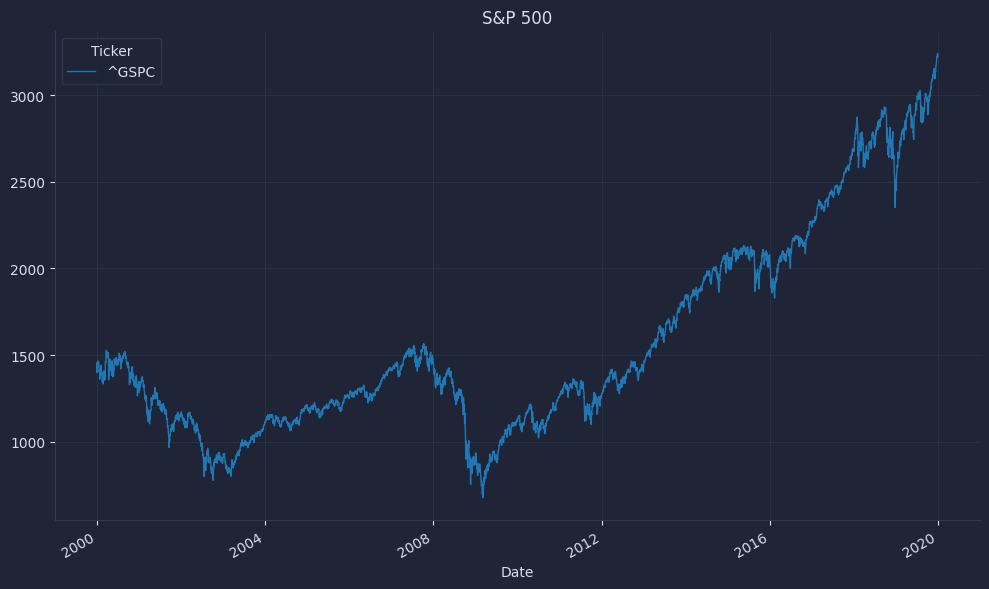

In [5]:
df = yf.download(
    "^GSPC", start="2000-01-01", end="2019-12-31"
).Close
df.plot(title="S&P 500")

Plotting the full series first gives us a visual reference for what the Hurst exponent will quantify. We can see obvious trending periods (like the post-2009 recovery) and choppy sideways stretches, which should correspond to different Hurst values when we compute them below.

## Define the Hurst exponent function

This function measures how the spread of price changes grows as we look at increasingly longer time intervals. The slope of that relationship on a log-log scale is the Hurst exponent.

In [6]:
def get_hurst_exponent(ts, max_lag=20):
    lags = range(2, max_lag)
    tau = [
        np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags
    ]

    return np.polyfit(np.log(lags), np.log(tau), 1)[0]

The key idea is that for a trending series, the standard deviation of lagged differences grows faster than it would for a random walk. By fitting a line through the log of lags versus the log of those standard deviations, we get a single slope value: above 0.5 means trending, below 0.5 means mean-reverting, and right at 0.5 means random. This is the core measurement that tells us which type of strategy fits the current market.

## Compute Hurst across different lag windows

We compute the Hurst exponent at several max-lag values to see whether the market's character changes depending on the time horizon we examine. A short lag captures recent behavior while a long lag reflects the dominant regime over the full dataset.

In [7]:
for lag in [20, 100, 250, 500, 1000]:
    hurst_exp = get_hurst_exponent(df.values, lag)
    print(f"{lag} lags: {hurst_exp:.4f}")

20 lags: 0.4481
100 lags: 0.4513
250 lags: 0.4918
500 lags: 0.5265
1000 lags: 0.5178


Checking multiple lag windows is how professionals avoid drawing conclusions from a single arbitrary setting. If the Hurst exponent is consistently above 0.5 across many lags, we have stronger evidence that the series is genuinely trending rather than just noisy at one particular scale.

Now we isolate a shorter window of the S&P 500 to see how the Hurst exponent behaves during a specific market period. The 2005-2007 stretch was a relatively steady bull market before the financial crisis, so we would expect trending behavior.

In [8]:
shorter_series = df.loc["2005":"2007"].values
for lag in [20, 100, 250, 500]:
    hurst_exp = get_hurst_exponent(shorter_series, lag)
    print(f"{lag} lags: {hurst_exp:.4f}")

20 lags: 0.3989
100 lags: 0.3215
250 lags: 0.2507
500 lags: 0.1258


This is the practical payoff of the entire exercise. By slicing different time windows and recalculating, we can measure whether the market regime has shifted before committing capital to a strategy. A beginner who checks this number regularly avoids the painful mistake described in the post: running a trend-following strategy in a market that is actually bouncing sideways.

<a href="https://pyquantnews.com/">PyQuant News</a> is where finance practitioners level up with Python for quant finance, algorithmic trading, and market data analysis. Looking to get started? Check out the fastest growing, top-selling course to <a href="https://www.pyquantnews.com/getting-started-with-python-for-quant-finance/">get started with Python for quant finance</a>. For educational purposes. Not investment advice. Use at your own risk.